# tap.svf~ — Simper SVF verification

`tap.svf~` is a trapezoidal-integration (TPT / zero-delay-feedback) state-variable
filter after Andy Simper's Cytomic papers — the lineage behind Ableton Live's filters,
including Auto Filter's Morph type. Orders 2/4/8 run as a Butterworth-spread cascade;
a continuous **morph** sweeps LP → BP → HP → notch with corners bit-identical to the
discrete modes; the parametric-EQ trio (bell/shelves) comes from Simper's coefficient
tables; and a **driven** circuit adds tanh band-node limiting with true bounded
self-oscillation at resonance 1.

Like the AmbiTap notebooks, this machine-checks the documented behavior against the
**actual C++ kernel** (`include/taptools/svf.h`, the same header `tap.svf~` compiles),
driven through the C ABI (`tools/capi`) via ctypes — not a Python re-implementation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = tap.PALETTE
fs = 48000


def spectrum_db(y, sr=fs):
    """Hann-windowed magnitude spectrum in dBFS-ish units."""
    n = len(y)
    w = np.hanning(n)
    Y = np.abs(np.fft.rfft(y * w)) / (np.sum(w) / 2)
    return np.fft.rfftfreq(n, 1 / sr), 20 * np.log10(Y + 1e-12)


def db_at(freqs, db, hz):
    return float(np.interp(hz, freqs, db))


def peak_freq(y, sr=fs, fmin=20.0):
    """Dominant frequency via parabolic interpolation on the windowed FFT peak."""
    freqs, db = spectrum_db(y, sr)
    sel = freqs >= fmin
    i = np.argmax(db[sel]) + np.searchsorted(freqs, fmin)
    if 0 < i < len(db) - 1:
        a, b, c = db[i - 1], db[i], db[i + 1]
        d = 0.5 * (a - c) / (a - 2 * b + c + 1e-30)
    else:
        d = 0.0
    return float((i + d) * sr / len(y))


def bode(f, n=1 << 15):
    """Exact transfer function of the (linear) filter via its impulse response."""
    x = np.zeros(n)
    x[0] = 1.0
    h = f.process(x)
    return np.fft.rfftfreq(n, 1 / fs), 20 * np.log10(np.abs(np.fft.rfft(h)) + 1e-12)


## 1. Butterworth flatness — −3 dB at fc, 12/24/48 dB per octave

At resonance 0 every order is maximally flat: the cascade uses the Butterworth Q
spread, so the response is −3.01 dB at the cutoff regardless of order, and the
asymptotic slope is 6 dB/oct per pole. We measure both from the exact impulse
response of the clean circuit.

order 2: -3.01 dB at fc (want -3.01), slope 12.3 dB/oct (want 12)
order 4: -3.01 dB at fc (want -3.01), slope 24.7 dB/oct (want 24)
order 8: -3.01 dB at fc (want -3.01), slope 49.4 dB/oct (want 48)


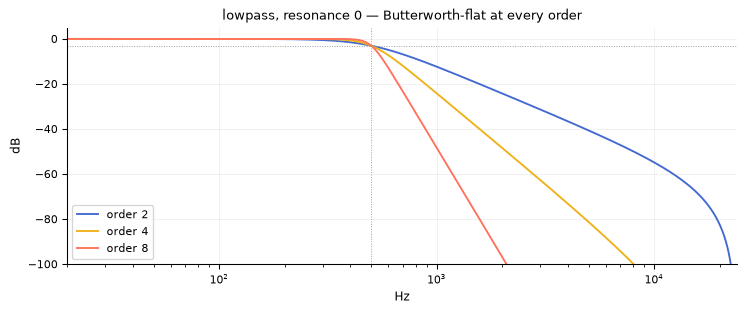

In [2]:
fc = 500.0
fig, ax = plt.subplots()
for i, order in enumerate((2, 4, 8)):
    f = tap.Svf(fs, frequency=fc, resonance=0.0, mode=tap.Svf.LOWPASS, order=order)
    freqs, db = bode(f)
    at_fc = db_at(freqs, db, fc)
    # slope 2-3 octaves above fc, well below Nyquist (the bilinear zero at fs/2 steepens
    # the far top end — physics of any digital filter, not part of the slope claim)
    slope = db_at(freqs, db, 2000) - db_at(freqs, db, 4000)
    expected = 6 * order
    print(f"order {order}: {at_fc:+.2f} dB at fc (want -3.01), "
          f"slope {slope:.1f} dB/oct (want {expected})")
    assert abs(at_fc + 3.01) < 0.3
    assert abs(slope - expected) < 1.5
    ax.semilogx(freqs[1:], db[1:], color=PAL[i], lw=1.4, label=f"order {order}")
ax.axvline(fc, color="0.6", lw=0.7, ls=":")
ax.axhline(-3.01, color="0.6", lw=0.7, ls=":")
ax.set(xlim=(20, 24000), ylim=(-100, 5), xlabel="Hz", ylabel="dB",
       title="lowpass, resonance 0 — Butterworth-flat at every order")
ax.legend()
plt.show()

## 2. The morph corners are bit-identical to the discrete modes

`mode_morph` sweeps the output mix continuously around LP (0) → BP (0.25) → HP (0.5)
→ notch (0.75) → LP (1). The corner positions must be **bit-identical** to the discrete
modes — the same guarantee the kernel's Catch suite pins — so morphing to a corner *is*
that filter, not an approximation of it.

morph 0.00 vs discrete mode 0: max |diff| = 0
morph 0.25 vs discrete mode 2: max |diff| = 0
morph 0.50 vs discrete mode 1: max |diff| = 0
morph 0.75 vs discrete mode 3: max |diff| = 0


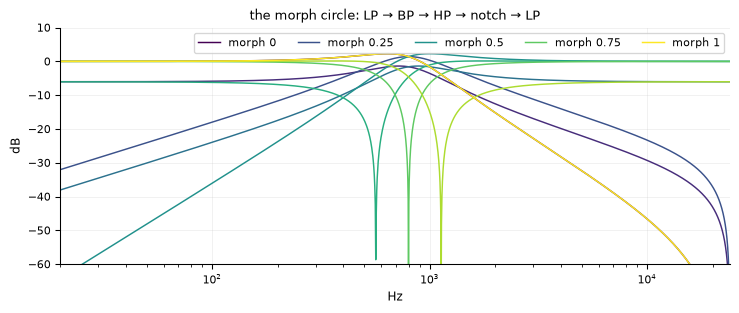

In [3]:
rng = np.random.default_rng(1)
noise = rng.standard_normal(fs // 2) * 0.3
corners = [(tap.Svf.LOWPASS, 0.00), (tap.Svf.BANDPASS, 0.25),
           (tap.Svf.HIGHPASS, 0.50), (tap.Svf.NOTCH, 0.75)]
for mode, morph in corners:
    a = tap.Svf(fs, frequency=800, resonance=0.4, mode=mode)
    b = tap.Svf(fs, frequency=800, resonance=0.4, mode=tap.Svf.MORPH, morph=morph)
    diff = np.max(np.abs(a.process(noise) - b.process(noise)))
    print(f"morph {morph:.2f} vs discrete mode {mode}: max |diff| = {diff:.3g}")
    assert diff == 0.0

fig, ax = plt.subplots()
for i, morph in enumerate(np.linspace(0.0, 1.0, 9)):
    f = tap.Svf(fs, frequency=800, resonance=0.4, mode=tap.Svf.MORPH, morph=morph)
    freqs, db = bode(f, 1 << 14)
    ax.semilogx(freqs[1:], db[1:], color=plt.cm.viridis(morph), lw=1.1,
                label=f"morph {morph:.3g}" if morph in (0.0, 0.25, 0.5, 0.75, 1.0) else None)
ax.set(xlim=(20, 24000), ylim=(-60, 10), xlabel="Hz", ylabel="dB",
       title="the morph circle: LP → BP → HP → notch → LP")
ax.legend(ncol=5)
plt.show()

## 3. The parametric-EQ modes hit their gain targets

Bell, low shelf, and high shelf come straight from Simper's coefficient tables and
are always a single 2nd-order section (cascading would square the boost). The bell
must peak at exactly the gain parameter at fc; the shelves must land the full gain
in their stop-side plateau and stay at 0 dB on the other.

bell peak +12.00 dB (want +12)
low shelf: -9.00 dB low side (want -9), -0.00 dB high side (want 0)
high shelf: +6.00 dB high side (want +6), +0.00 dB low side (want 0)


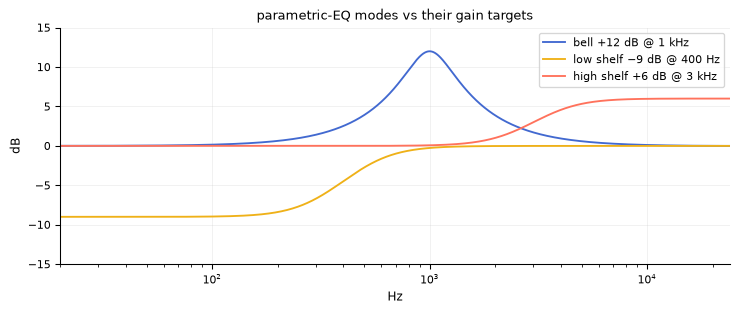

In [4]:
fig, ax = plt.subplots()
f = tap.Svf(fs, frequency=1000, resonance=0.3, mode=tap.Svf.BELL, gain=12.0)
freqs, db = bode(f)
bell_peak = db_at(freqs, db, 1000)
ax.semilogx(freqs[1:], db[1:], color=PAL[0], lw=1.4, label="bell +12 dB @ 1 kHz")

f = tap.Svf(fs, frequency=400, resonance=0.0, mode=tap.Svf.LOWSHELF, gain=-9.0)
freqs, db = bode(f)
ls_low, ls_high = db_at(freqs, db, 25), db_at(freqs, db, 8000)
ax.semilogx(freqs[1:], db[1:], color=PAL[1], lw=1.4, label="low shelf −9 dB @ 400 Hz")

f = tap.Svf(fs, frequency=3000, resonance=0.0, mode=tap.Svf.HIGHSHELF, gain=6.0)
freqs, db = bode(f)
hs_high, hs_low = db_at(freqs, db, 16000), db_at(freqs, db, 60)
ax.semilogx(freqs[1:], db[1:], color=PAL[2], lw=1.4, label="high shelf +6 dB @ 3 kHz")

print(f"bell peak {bell_peak:+.2f} dB (want +12)")
print(f"low shelf: {ls_low:+.2f} dB low side (want -9), {ls_high:+.2f} dB high side (want 0)")
print(f"high shelf: {hs_high:+.2f} dB high side (want +6), {hs_low:+.2f} dB low side (want 0)")
assert abs(bell_peak - 12) < 0.5
assert abs(ls_low + 9) < 0.5 and abs(ls_high) < 0.5
assert abs(hs_high - 6) < 0.5 and abs(hs_low) < 0.5
ax.set(xlim=(20, 24000), ylim=(-15, 15), xlabel="Hz", ylabel="dB",
       title="parametric-EQ modes vs their gain targets")
ax.legend()
plt.show()

## 4. The driven circuit self-oscillates — bounded, at the cutoff

`circuit_driven` puts a tanh limiter on each section's band node. At resonance 1.0
the resonant section is tuned slightly past the oscillation threshold, so after a
ping it **sings at the cutoff frequency** with the saturator bounding the amplitude
(an all-zero state is a fixed point — hence the ping). Drive adds odd harmonics
(the tanh is symmetric).

self-oscillation: 999.7 Hz (cutoff 1000), peak |y| = 0.10


3rd harmonic of a 200 Hz tone: +143.4 dB louder driven than clean


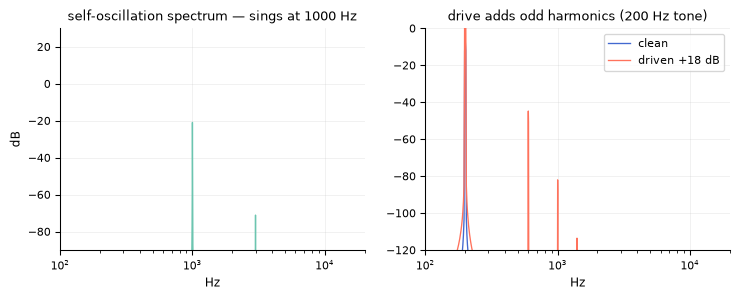

In [5]:
f = tap.Svf(fs, frequency=1000, resonance=1.0, mode=tap.Svf.LOWPASS,
            circuit=tap.Svf.DRIVEN, oversample=2)
ping = np.zeros(2 * fs)
ping[0] = 0.5
y = f.process(ping)
tail = y[fs:]
osc_f = peak_freq(tail)
print(f"self-oscillation: {osc_f:.1f} Hz (cutoff 1000), peak |y| = {np.abs(tail).max():.2f}")
assert abs(osc_f - 1000) / 1000 < 0.02
assert 0.05 < np.abs(tail).max() < 32.0

t = np.arange(fs) / fs
tone = 0.5 * np.sin(2 * np.pi * 200 * t)
clean = tap.Svf(fs, frequency=4000, resonance=0.3, mode=tap.Svf.LOWPASS).process(tone)
driven = tap.Svf(fs, frequency=4000, resonance=0.3, mode=tap.Svf.LOWPASS,
                 circuit=tap.Svf.DRIVEN, drive=18.0, oversample=2).process(tone)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(9, 3.0))
fr, db = spectrum_db(tail)
ax0.semilogx(fr[1:], db[1:], color=PAL[3], lw=1.0)
ax0.set(xlim=(100, 20000), ylim=(-90, 30), xlabel="Hz", ylabel="dB",
        title=f"self-oscillation spectrum — sings at {osc_f:.0f} Hz")
for y2, c, lbl in ((clean, PAL[0], "clean"), (driven, PAL[2], "driven +18 dB")):
    fr, db = spectrum_db(y2[fs // 2:])
    ax1.semilogx(fr[1:], db[1:], color=c, lw=1.0, label=lbl)
h3_gain = db_at(*spectrum_db(driven[fs // 2:]), 600) - db_at(*spectrum_db(clean[fs // 2:]), 600)
print(f"3rd harmonic of a 200 Hz tone: {h3_gain:+.1f} dB louder driven than clean")
assert h3_gain > 20
ax1.set(xlim=(100, 20000), ylim=(-120, 0), xlabel="Hz",
        title="drive adds odd harmonics (200 Hz tone)")
ax1.legend()
plt.show()

## 5. Per-sample cutoff modulation is unconditionally stable

The TPT core needs no oversampling trick to survive audio-rate cutoff modulation —
the reason this kernel could become `tap.autowah~`'s sweep engine. We slam the cutoff
with a 90 Hz exponential LFO across 5+ octaves under full-band noise and check the
output stays bounded and finite.

audio-rate swept output: max |y| = 1.17, all finite = True


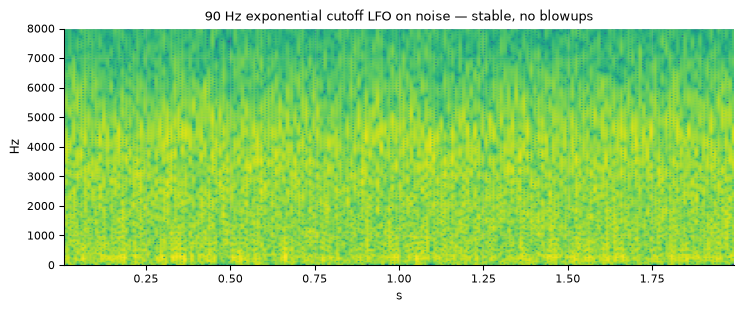


All tap.svf~ claims verified against the shipping kernel.


In [6]:
rng = np.random.default_rng(2)
n = 2 * fs
noise = rng.standard_normal(n) * 0.3
t = np.arange(n) / fs
cutoff = 150.0 * 2 ** (2.5 + 2.5 * np.sin(2 * np.pi * 90 * t))    # 150 Hz .. ~4.8 kHz at 90 Hz
f = tap.Svf(fs, resonance=0.8, mode=tap.Svf.LOWPASS)
y = f.process(noise, cutoff_hz=cutoff)
print(f"audio-rate swept output: max |y| = {np.abs(y).max():.2f}, all finite = {np.isfinite(y).all()}")
assert np.isfinite(y).all() and np.abs(y).max() < 10

fig, ax = plt.subplots()
ax.specgram(y, NFFT=1024, Fs=fs, noverlap=768, cmap="viridis", vmin=-140)
ax.set(ylim=(0, 8000), xlabel="s", ylabel="Hz",
       title="90 Hz exponential cutoff LFO on noise — stable, no blowups")
plt.show()

print("\nAll tap.svf~ claims verified against the shipping kernel.")